!pip install matplotlib

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def hadamard():
    return (1/np.sqrt(2)) * np.array([[1, 1],
                                      [1, -1]])

def shift_operator(state):
    n_positions = state.shape[0]
    new_state = np.zeros_like(state, dtype=complex)

    for x in range(n_positions):
        # |+> → direita
        if x + 1 < n_positions:
            new_state[x + 1, 0] += state[x, 0]

        # |-> → esquerda
        if x - 1 >= 0:
            new_state[x - 1, 1] += state[x, 1]

    return new_state

def coin_operator(state, C):
    return np.einsum('ij,xj->xi', C, state)

def quantum_walk(n_steps, n_positions):
    state = np.zeros((n_positions, 2), dtype=complex)

    center = n_positions // 2

    # estado inicial SIMÉTRICO (importante pro formato em U)
    state[center] = (1/np.sqrt(2)) * np.array([1, 1j])

    C = hadamard()

    for _ in range(n_steps):
        state = coin_operator(state, C)
        state = shift_operator(state)

    return state

def probability_distribution(state):
    return np.sum(np.abs(state)**2, axis=1)

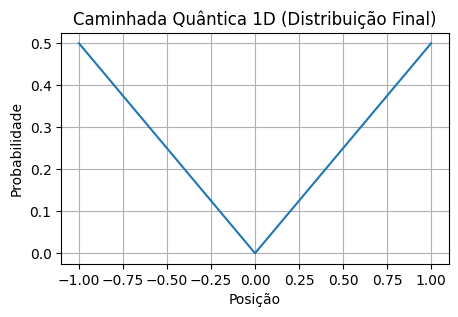

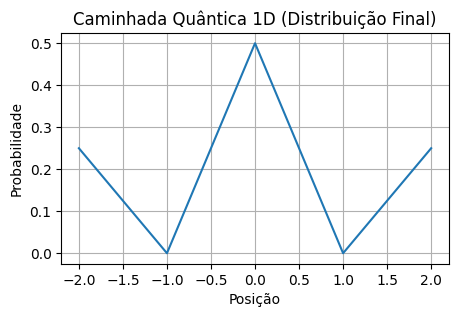

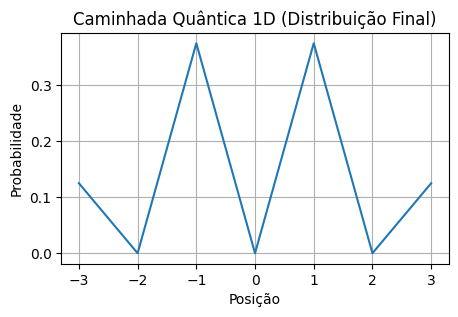

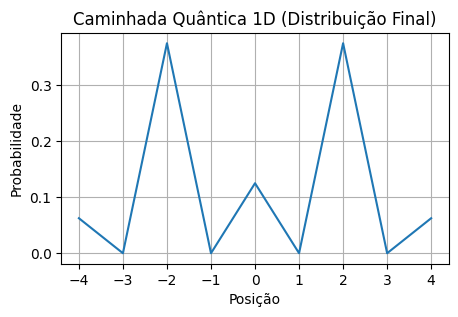

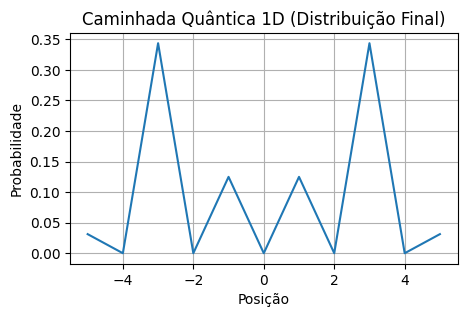

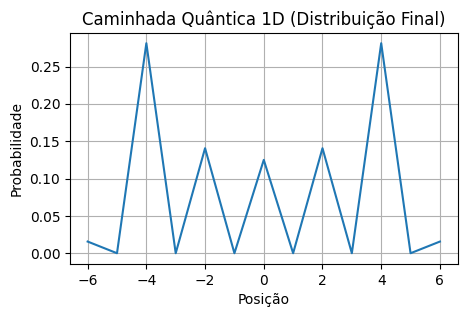

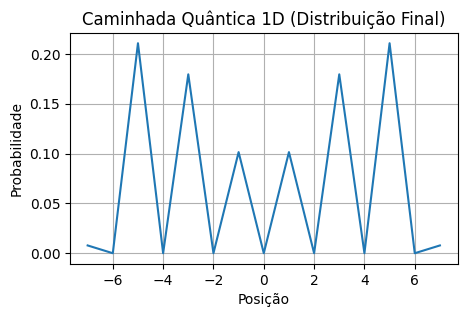

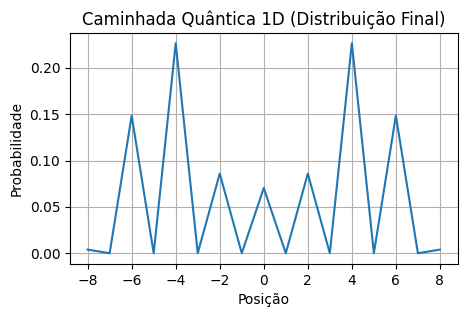

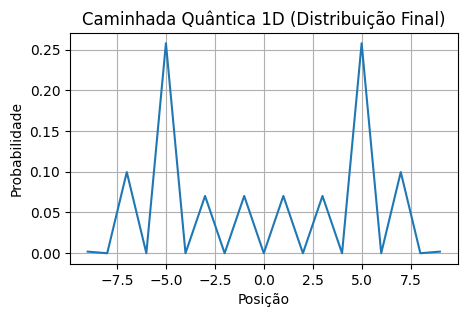

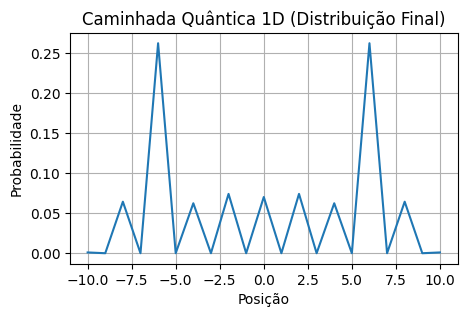

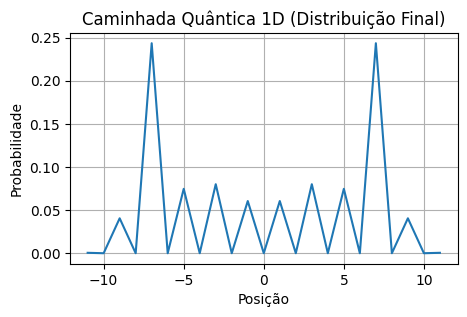

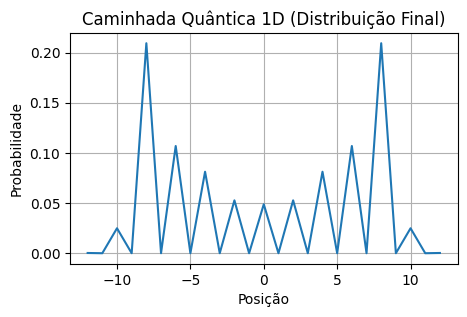

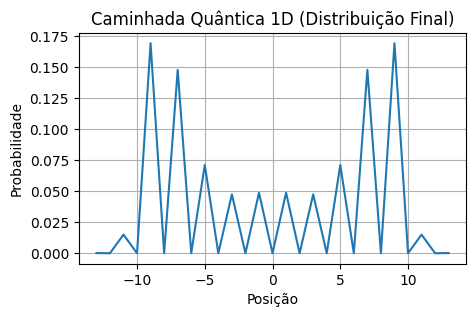

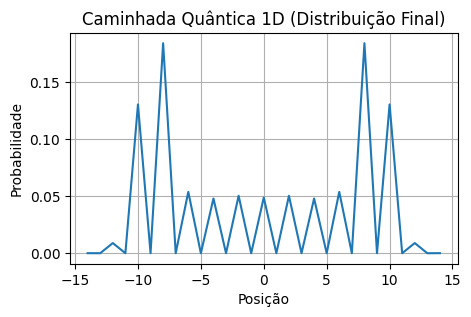

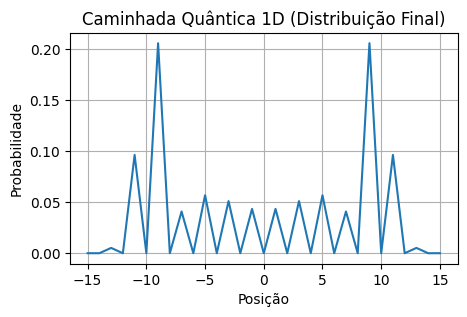

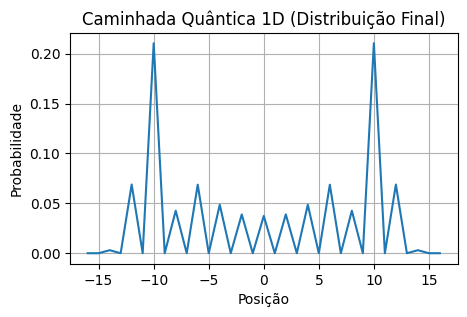

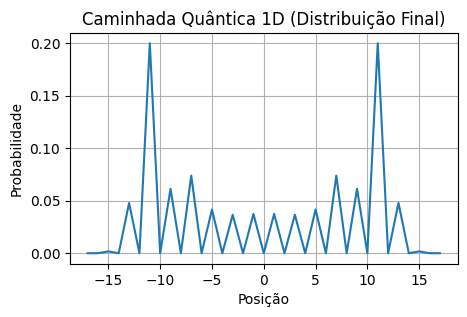

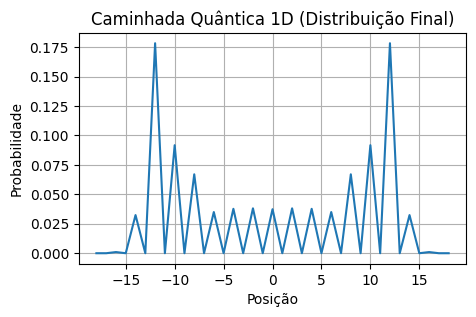

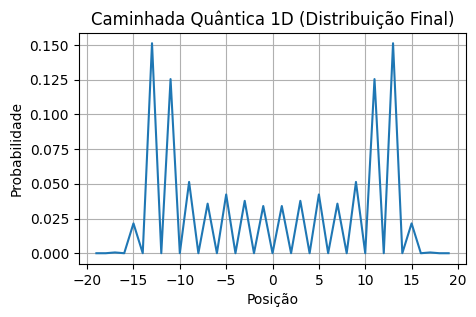

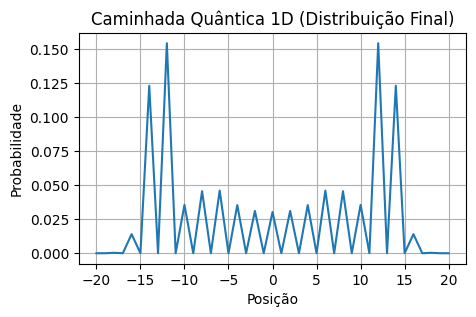

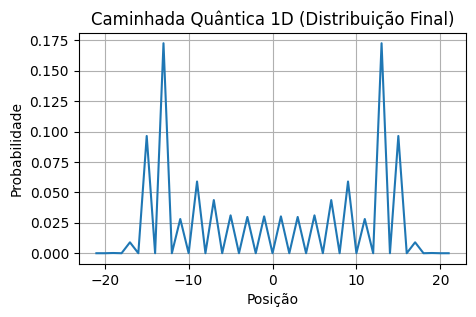

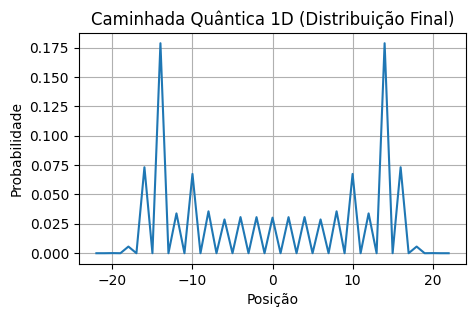

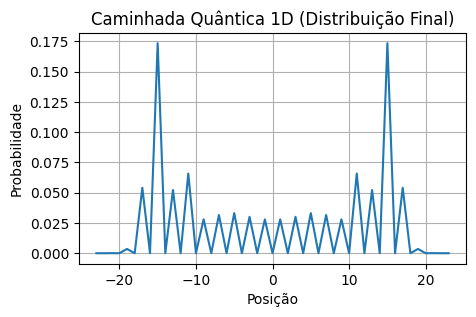

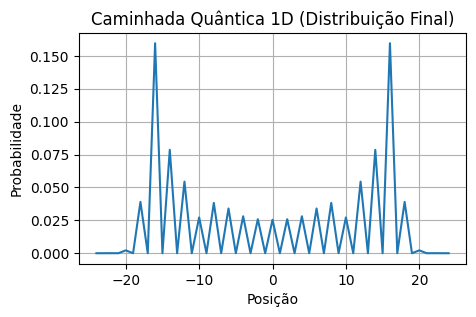

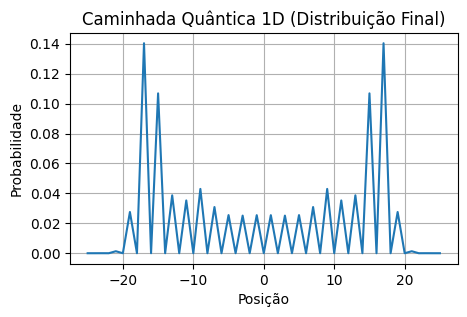

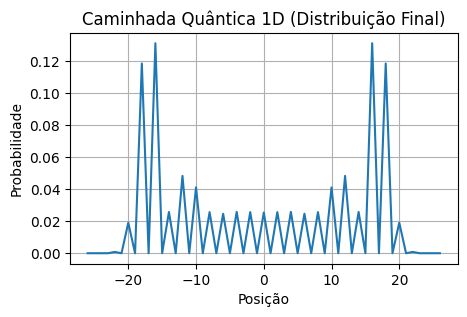

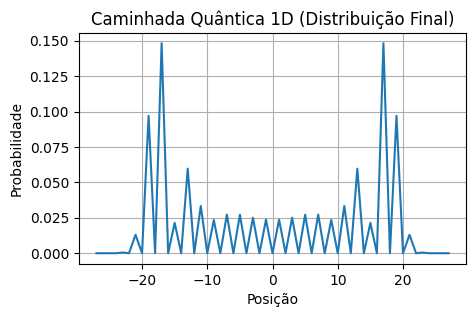

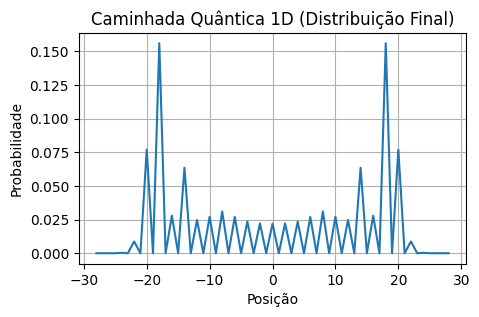

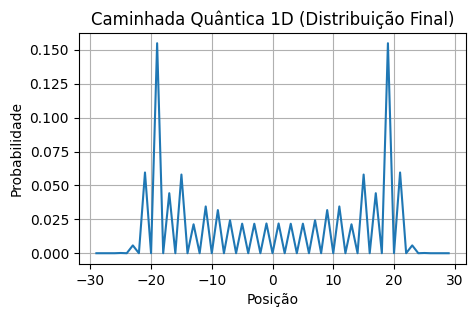

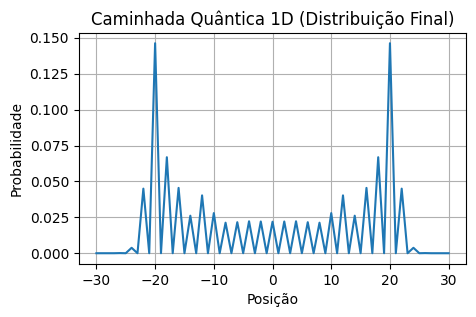

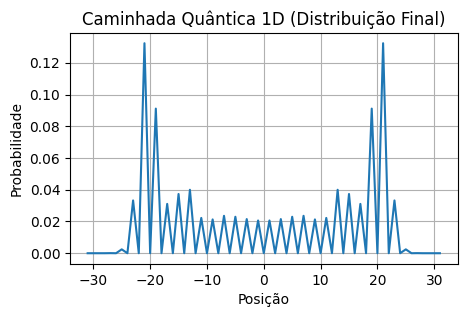

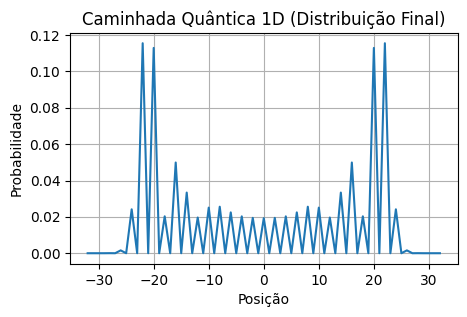

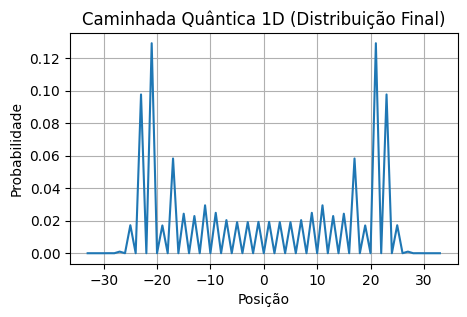

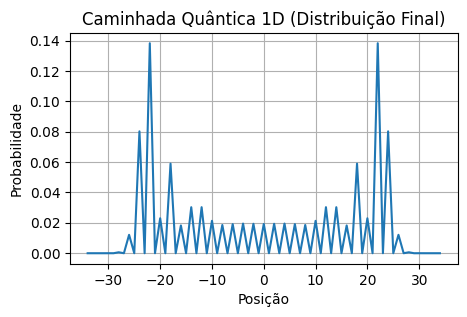

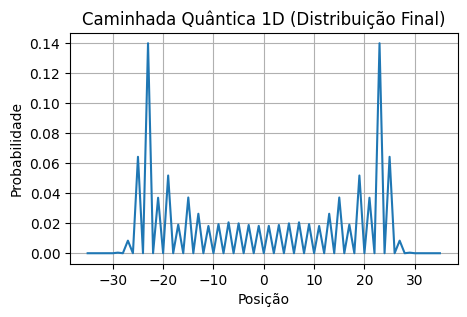

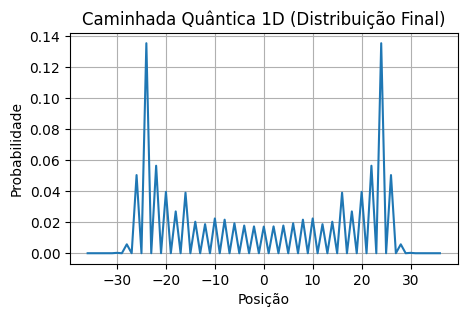

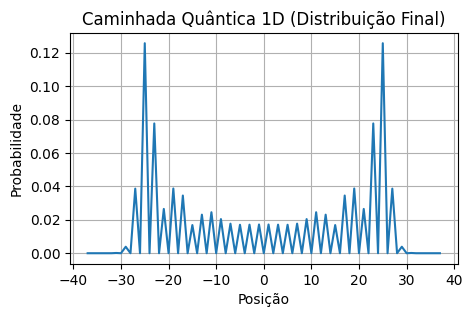

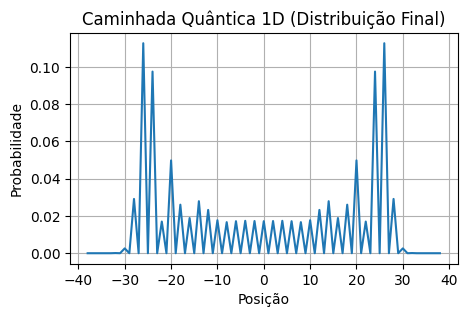

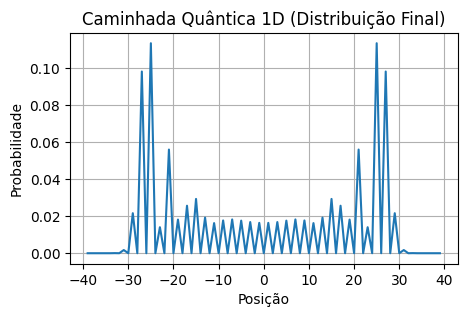

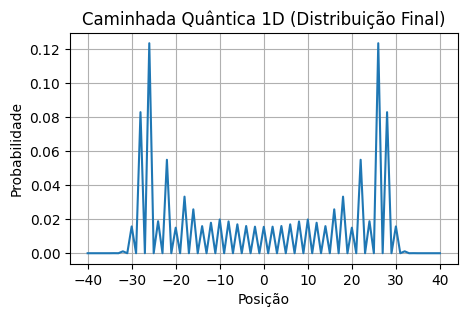

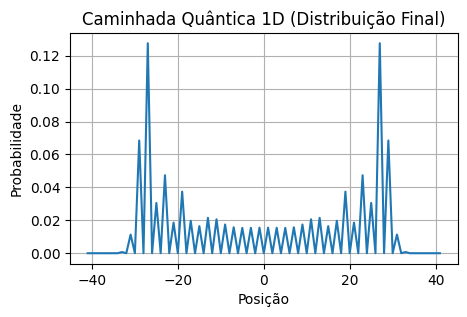

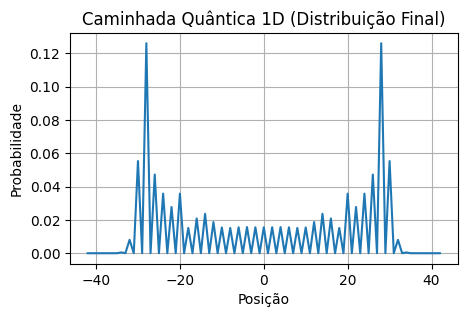

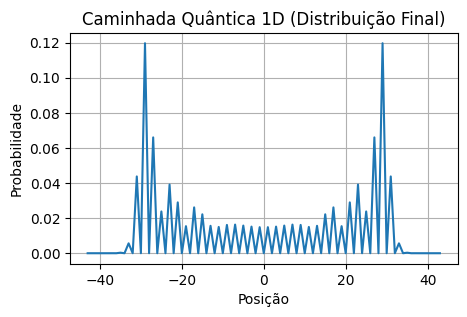

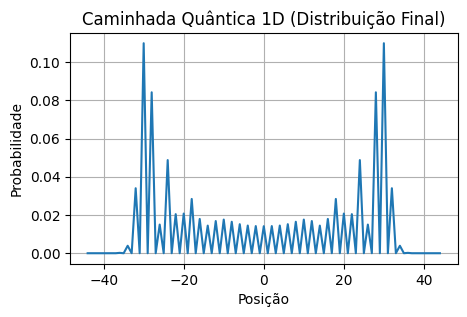

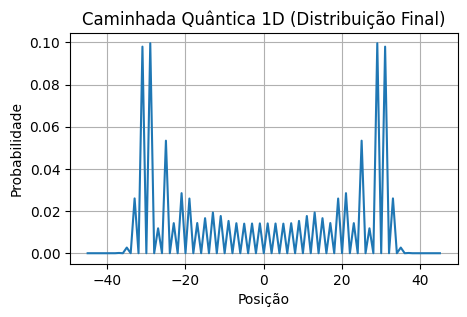

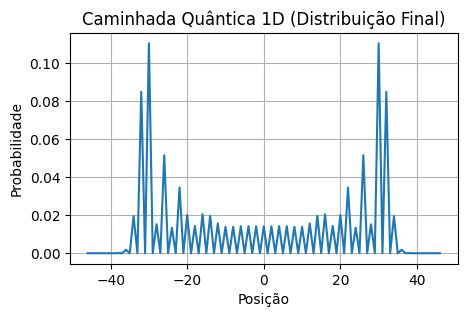

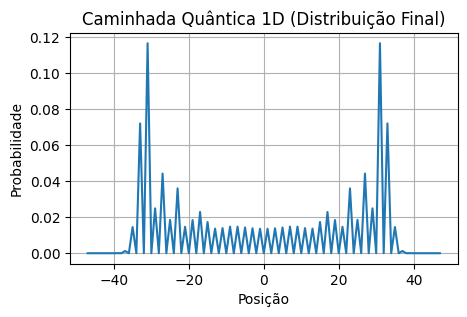

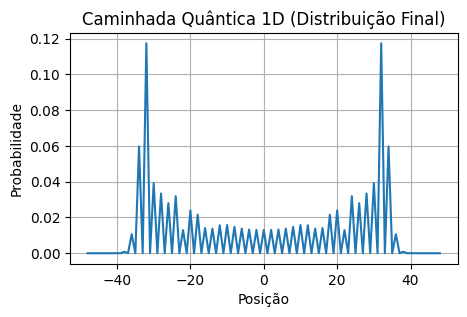

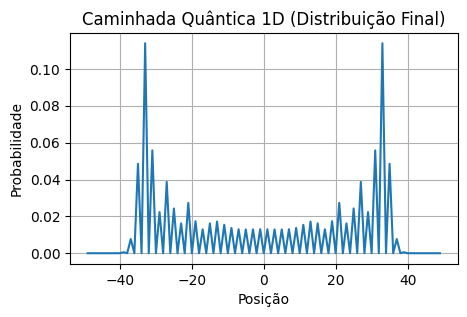

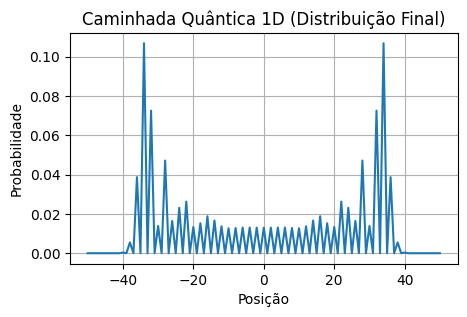

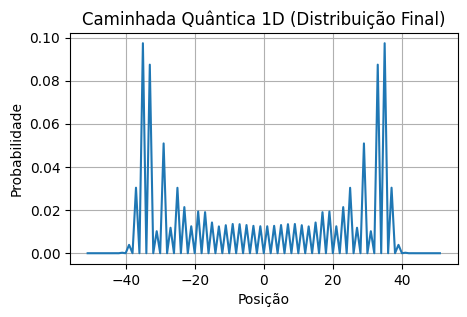

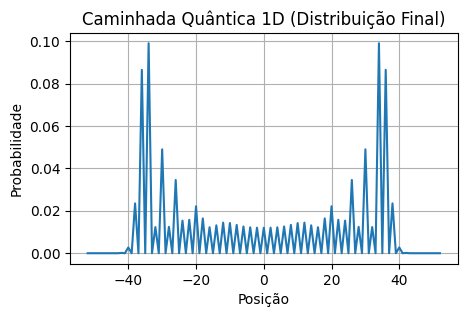

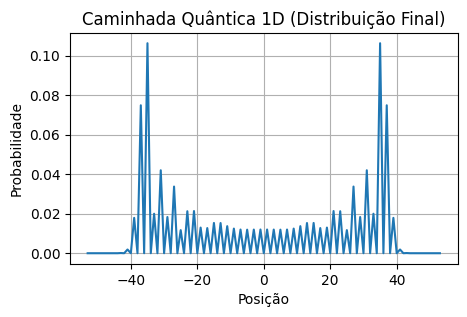

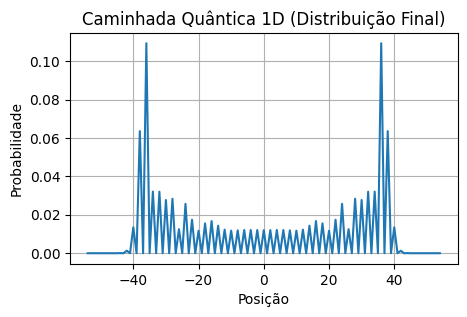

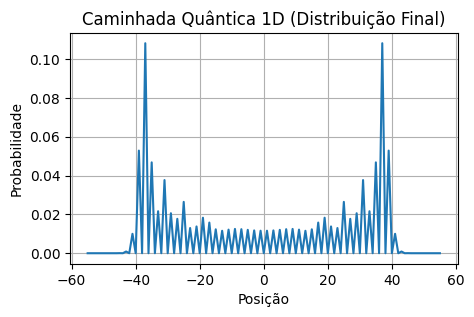

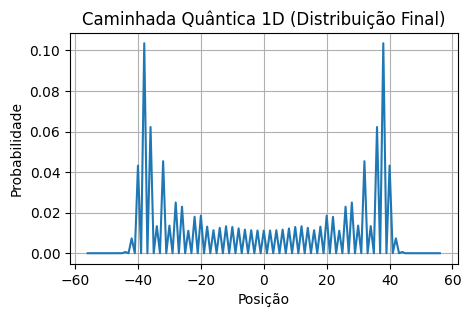

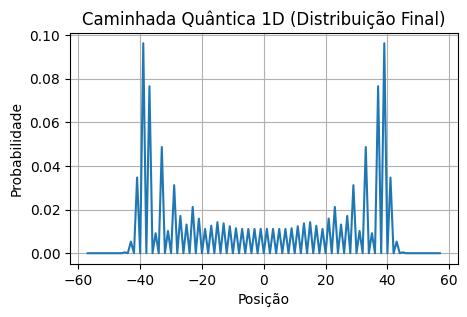

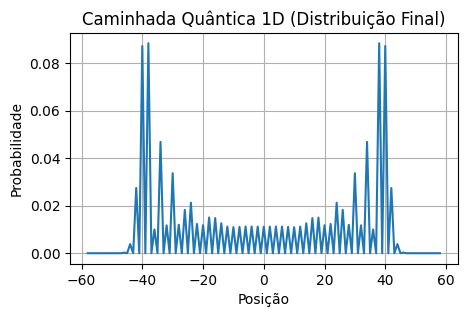

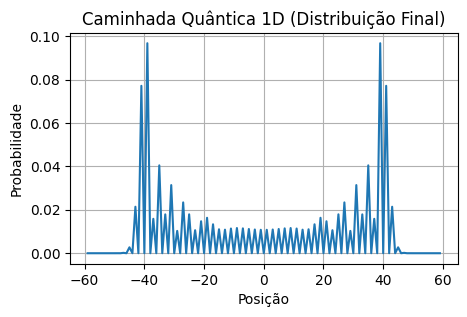

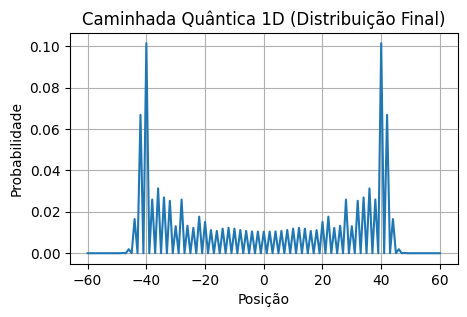

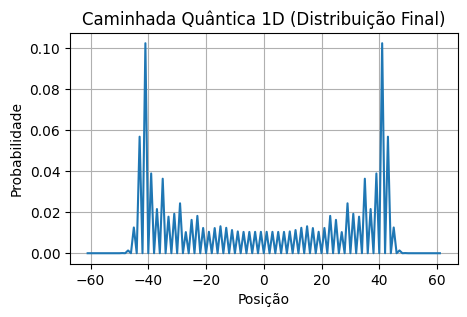

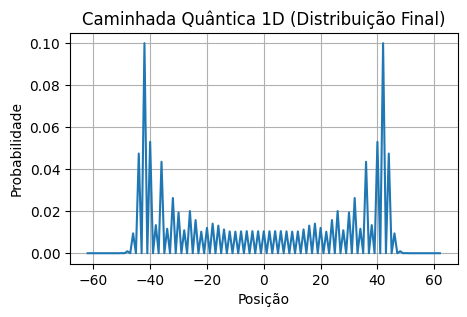

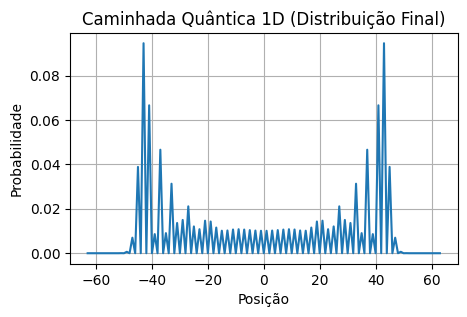

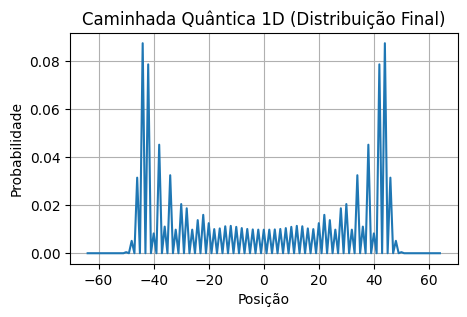

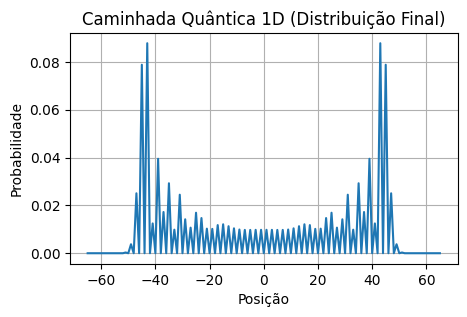

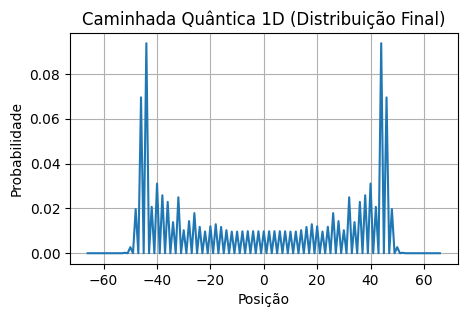

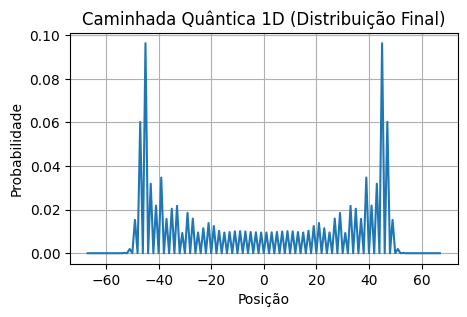

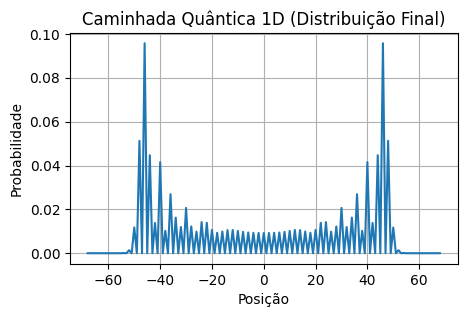

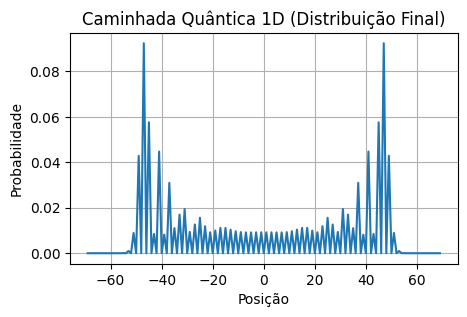

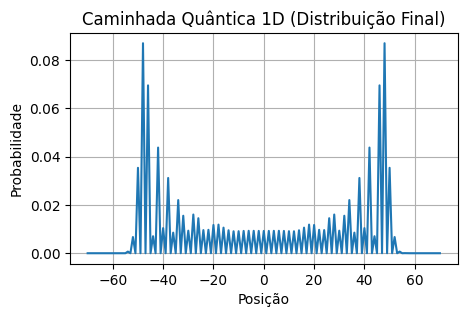

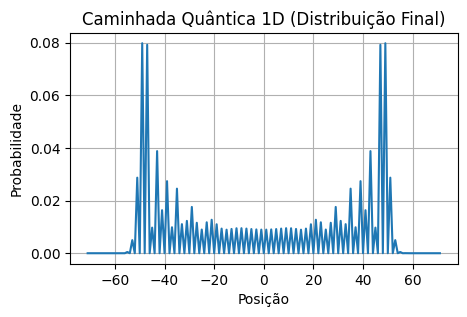

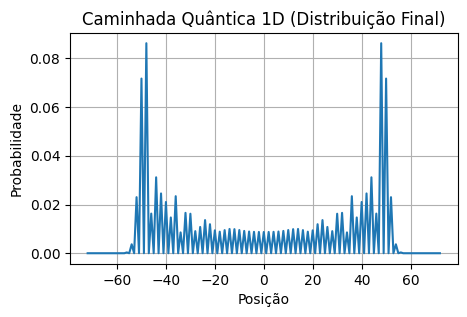

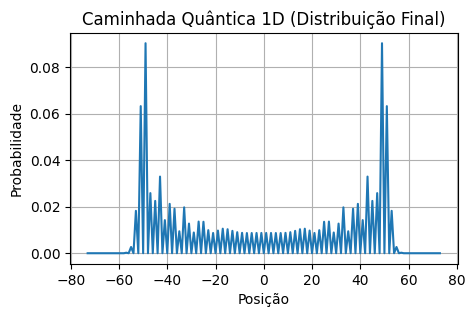

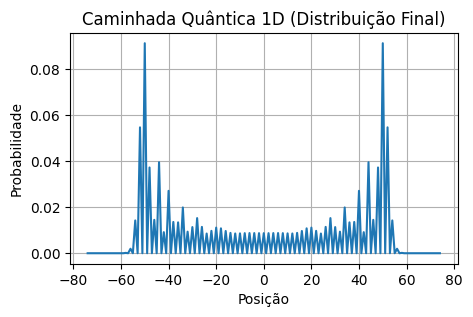

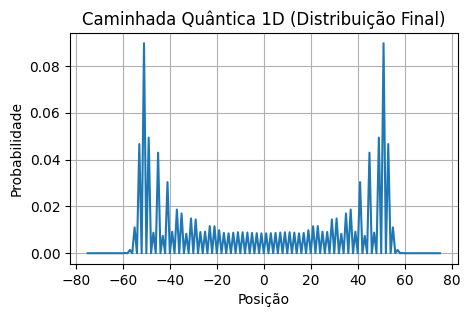

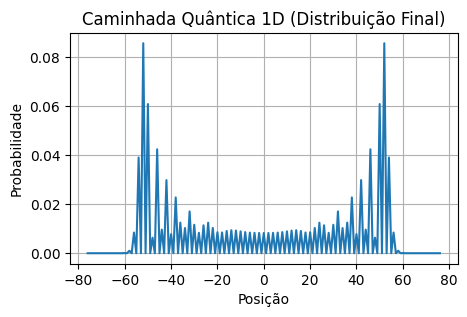

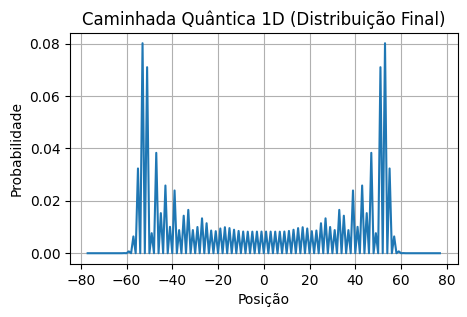

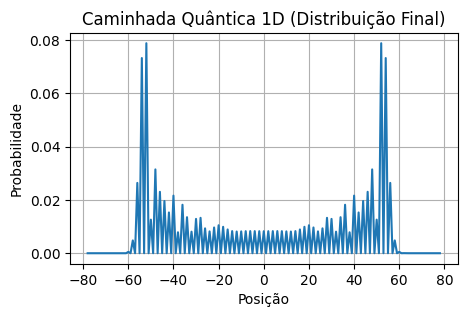

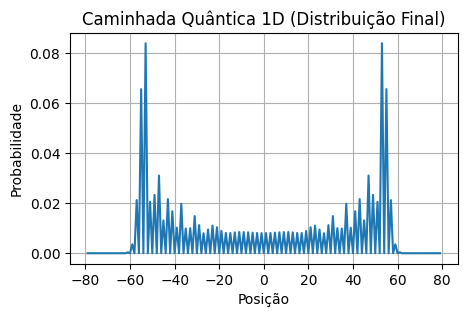

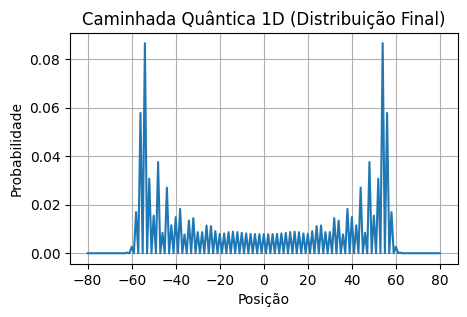

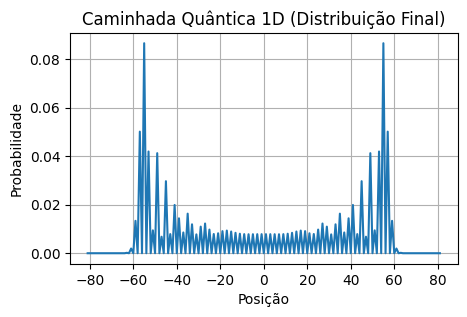

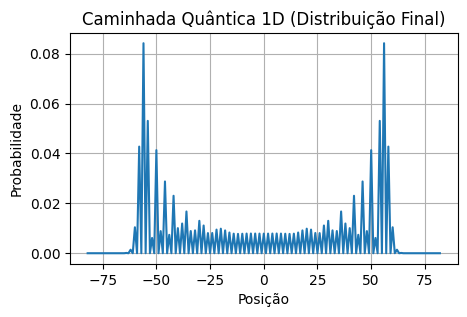

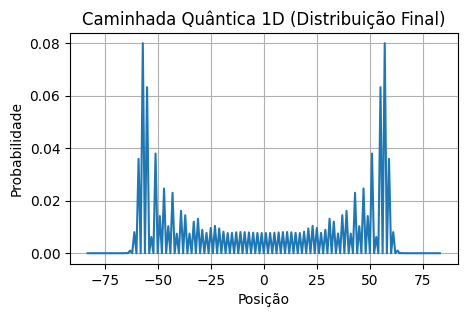

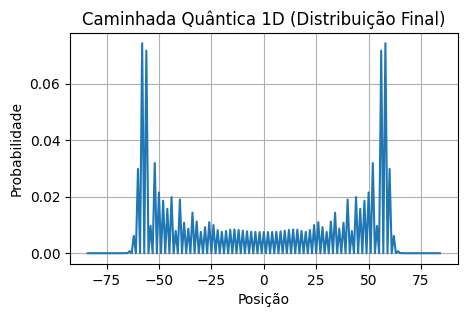

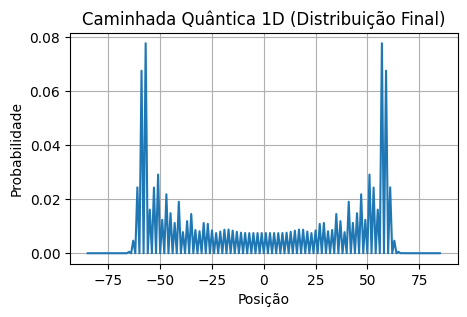

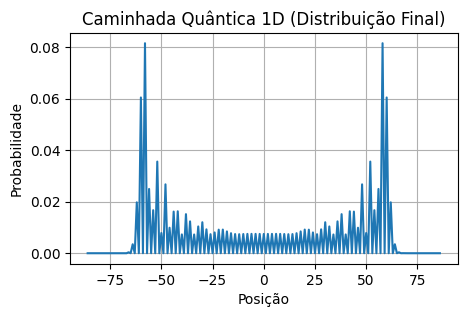

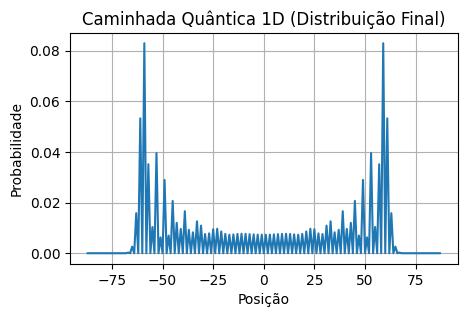

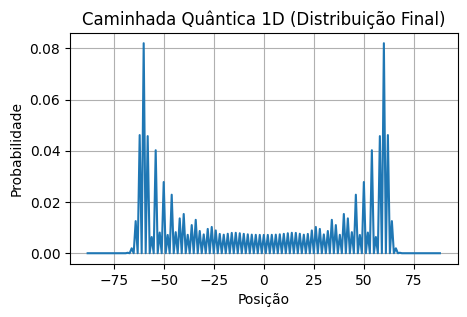

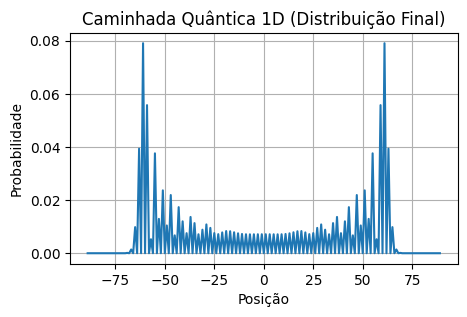

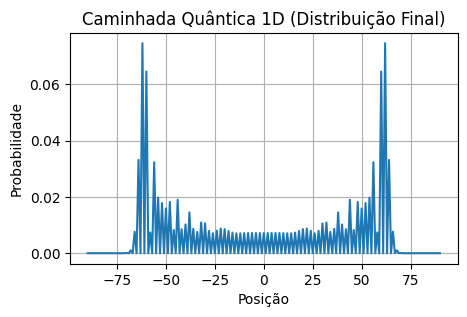

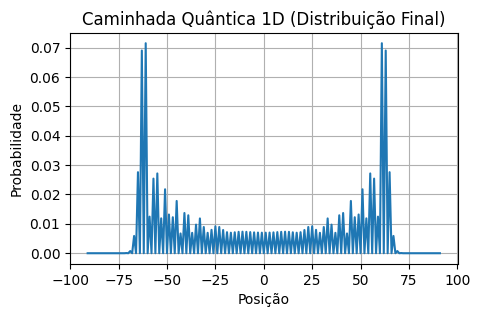

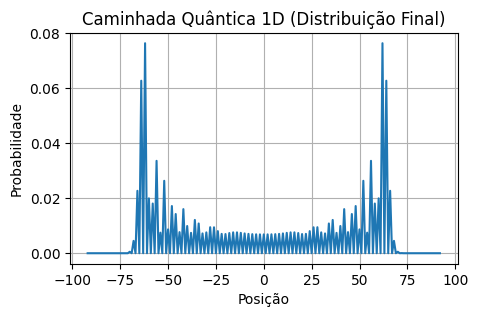

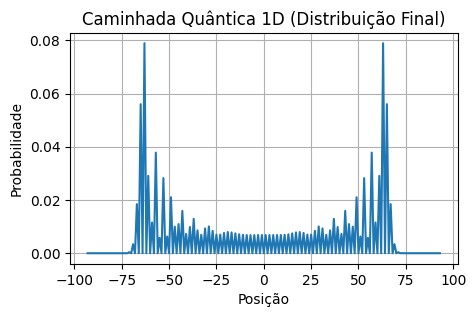

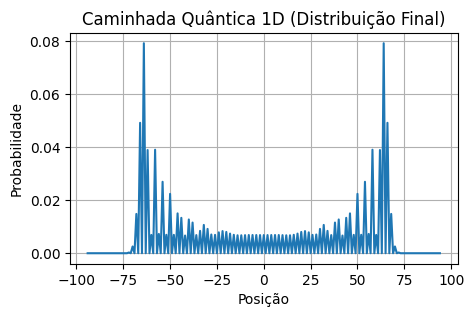

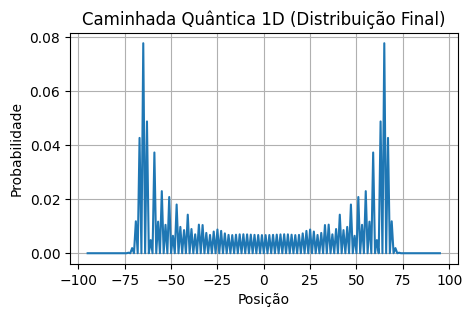

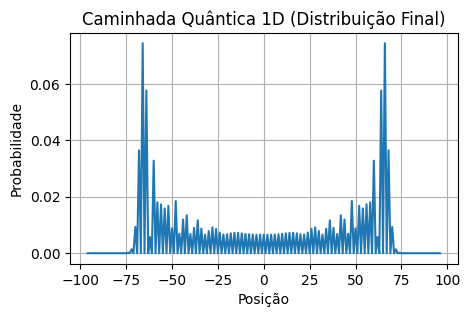

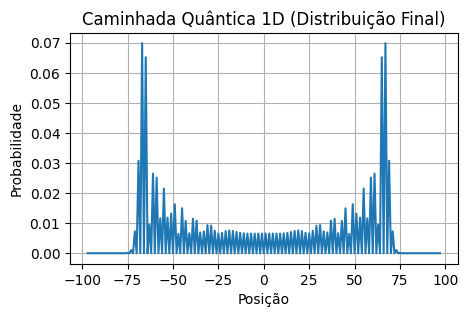

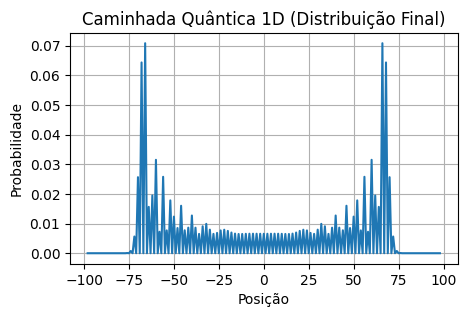

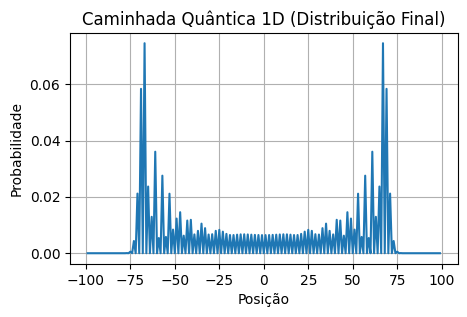

In [18]:
# =========================
# Parâmetros
# =========================

n_steps = 100

for n in range(1,n_steps):
    n_positions = 2 * n + 1

    state = quantum_walk(n, n_positions)
    prob = probability_distribution(state)

    positions = np.arange(n_positions) - n_positions // 2

    # =========================
    # Gráfico
    # =========================

    plt.figure(figsize=(5,3))
    plt.plot(positions, prob)
    plt.title("Caminhada Quântica 1D (Distribuição Final)")
    plt.xlabel("Posição")
    plt.ylabel("Probabilidade")
    plt.grid()

    plt.show()